# Movie Sentiment Analysis

Dataset link : https://ai.stanford.edu/~amaas/data/sentiment/

Kaggle Dataset link : https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews

In [39]:
# Import pandas to load and work with tabular data.
import pandas as pd

In [40]:
# Load the IMDb review dataset from the local data folder into a DataFrame.
url_path = "data/IMDB Dataset.csv"
df_original = pd.read_csv(url_path)

In [41]:
# Create a reference to the original dataset so the source data remains available.
df = df_original

In [42]:
# Make a deep copy so later cleaning steps do not modify the original data.
df = df_original.copy(deep=True)

# Basic Info

In [43]:
# Show the column names so we can see what features are available in the dataset.
print(df.columns.to_list())

['review', 'sentiment']


In [44]:
# Preview the first few rows to quickly inspect the structure and sample content.
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [45]:
# Print a concise summary of the dataframe, including column dtypes and missing values.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 781.4 KB


In [46]:
# Show basic descriptive statistics for the numeric fields in the dataset.
df.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [47]:
# Compute the number of duplicate rows by subtracting the count of unique rows from the full row count.
50000 - 49582 # no of duplicate rows

418

In [48]:
# Count how many reviews belong to each sentiment class.
df['sentiment'].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

# Descriptive Stats

In [49]:
# Import visualization libraries for plotting charts and distributions.
import matplotlib.pyplot as plt
import seaborn as sns

In [50]:
# Create new features that measure review length in characters and words.
# The lambda function splits the review text on whitespace to count words.
df['review_char_len'] = df['review'].apply(len)
df['review_word_len'] = df['review'].apply(lambda x: len(x.split()))

# Print descriptive statistics for the new length features.
print(df[['review_char_len','review_word_len']].describe())

       review_char_len  review_word_len
count     50000.000000     50000.000000
mean       1309.431020       231.156940
std         989.728014       171.343997
min          32.000000         4.000000
25%         699.000000       126.000000
50%         970.000000       173.000000
75%        1590.250000       280.000000
max       13704.000000      2470.000000


In [51]:
# This cell is a note for exploring whether very short or very long reviews are linked to sentiment.
# It is a placeholder for a possible follow-up analysis.

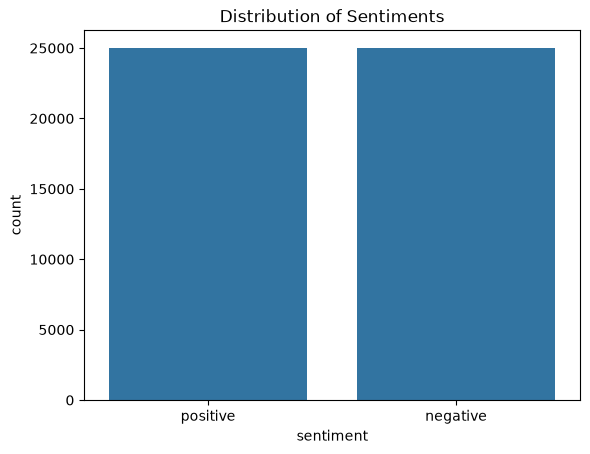

In [52]:
# Plot the sentiment distribution to see whether the classes are balanced.
sns.countplot(x='sentiment', data=df)
plt.title("Distribution of Sentiments")
plt.show()

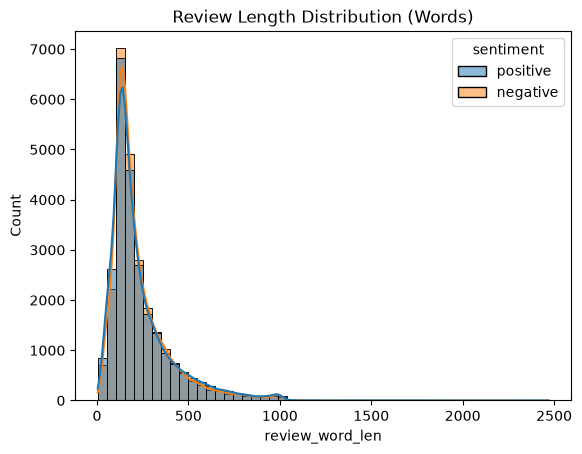

In [53]:
# Plot a histogram of review lengths with separate colors for each sentiment class.
sns.histplot(data=df, x='review_word_len', bins=50, hue='sentiment', kde=True)
plt.title("Review Length Distribution (Words)")
plt.show()

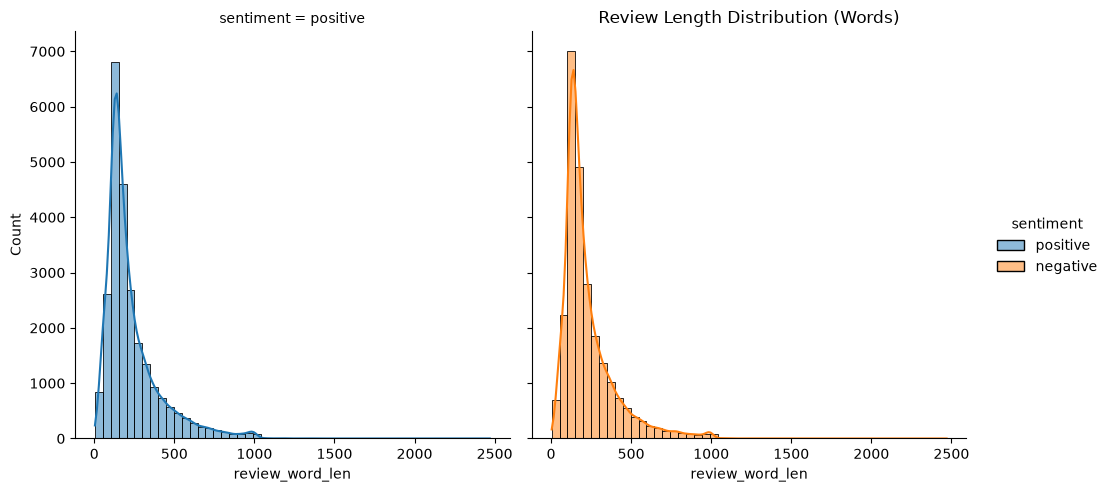

In [54]:
# Create faceted histograms so each sentiment class is shown in its own subplot.
sns.displot(data=df, x='review_word_len', bins=50, col="sentiment", hue='sentiment', kde=True)
plt.title("Review Length Distribution (Words)")
plt.show()

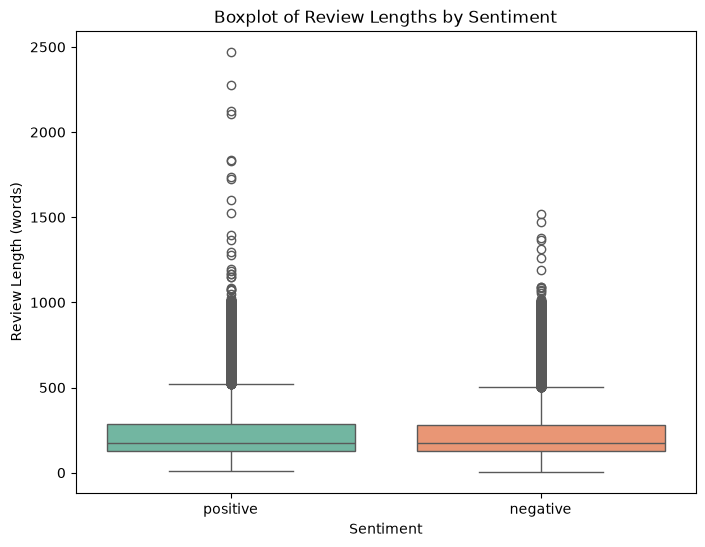

In [55]:
# Draw a boxplot to compare review length distributions across positive and negative sentiments.
plt.figure(figsize=(8,6))
sns.boxplot(x="sentiment", y="review_word_len", data=df, palette="Set2", hue="sentiment")
plt.title("Boxplot of Review Lengths by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Review Length (words)")
plt.show()

# Removing outliers

In [56]:
# Import numpy for numerical operations used in the outlier analysis.
import numpy as np

In [57]:
# Calculate the first quartile, third quartile, and interquartile range for review length.
# These values are used to define the outlier thresholds.
Q1 = df['review_word_len'].quantile(0.25)
Q3 = df['review_word_len'].quantile(0.75)
IQR = Q3 - Q1

In [58]:
# Define the lower and upper bounds for outlier detection using the 1.5 IQR rule.
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: -105.0
Upper Bound: 511.0


In [59]:
# Filter rows that fall outside the outlier thresholds and store them separately.
outliers = df[(df['review_word_len'] < lower_bound) | (df['review_word_len'] > upper_bound)]
# DF of outliers

In [60]:
# Print the number of rows identified as outliers.
print("Number of outliers:", outliers.shape[0])

Number of outliers: 3708


In [61]:
# This is a manual subtraction showing the difference between the full dataset size and the number of outliers.
50000-3708

46292

In [62]:
# Remove rows outside the valid IQR range to create a cleaner dataset for further analysis.
df_clean_from_iqr = df[(df['review_word_len'] >= lower_bound) & (df['review_word_len'] <= upper_bound)]
print("Orignal Data :", df.shape[0])
print("Cleaned Data :", df_clean_from_iqr.shape[0])

Orignal Data : 50000
Cleaned Data : 46292


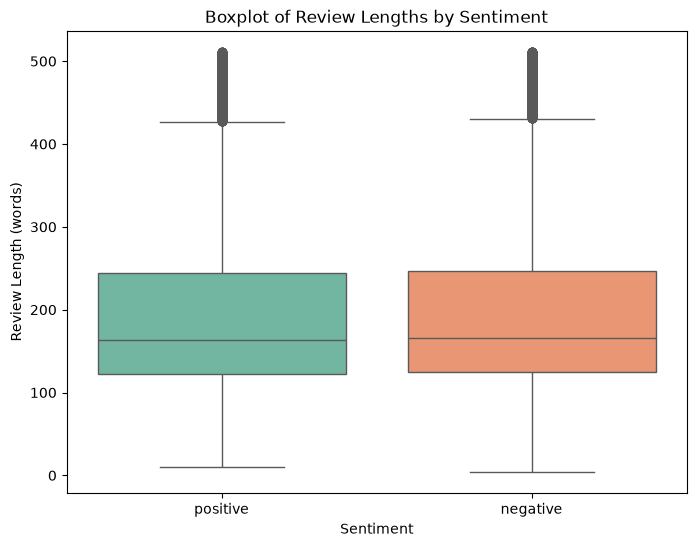

In [63]:
# Visualize the cleaned data to confirm the outlier removal improved the distribution.
plt.figure(figsize=(8,6))
sns.boxplot(x="sentiment", y="review_word_len", data=df_clean_from_iqr, palette="Set2", hue="sentiment")
plt.title("Boxplot of Review Lengths by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Review Length (words)")
plt.show()

In [64]:
# Preview the cleaned dataframe to confirm the filtered rows are in place.
df_clean_from_iqr.head()

,review,sentiment,review_char_len,review_word_len
0,One of the other reviewers has mentioned that ...,positive,1761,307
1,A wonderful little production. <br /><br />The...,positive,998,162
2,I thought this was a wonderful way to spend ti...,positive,926,166
3,Basically there's a family where a little boy ...,negative,748,138
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1317,230


In [65]:
# These lines are placeholders for a future feature-engineering step focused on sentiment-related words.
# The idea is to count positive and negative words separately for each review.
# how many positive words in a positive case -->
# how many negative words in a negative case -->

In [66]:
50000-3708

46292

In [67]:
# FE STEP
df_clean_from_iqr = df[(df['review_word_len'] >= lower_bound) & (df['review_word_len'] <= upper_bound)]
print("Orignal Data :", df.shape[0])
print("Cleaned Data :", df_clean_from_iqr.shape[0])

Orignal Data : 50000
Cleaned Data : 46292


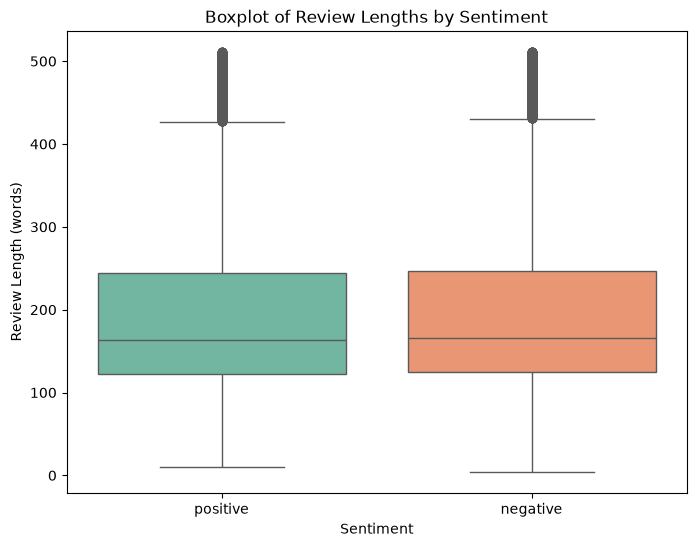

In [68]:
# Boxplot of Review Length by Sentiment
plt.figure(figsize=(8,6))
sns.boxplot(x="sentiment", y="review_word_len", data=df_clean_from_iqr, palette="Set2", hue="sentiment")
plt.title("Boxplot of Review Lengths by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Review Length (words)")
plt.show()

In [69]:
df_clean_from_iqr.head()

,review,sentiment,review_char_len,review_word_len
0,One of the other reviewers has mentioned that ...,positive,1761,307
1,A wonderful little production. <br /><br />The...,positive,998,162
2,I thought this was a wonderful way to spend ti...,positive,926,166
3,Basically there's a family where a little boy ...,negative,748,138
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1317,230


In [70]:
# how many positive words in a positive case -->
# how many negative words in a negative case -->

# Most common Words (Positive vs Negative)

In [71]:
# !pip install nltk

In [72]:
from collections import Counter
import re
import nltk # a library for natural language processing tasks
from nltk.corpus import stopwords

In [73]:
nltk.download('stopwords') # Download the stopwords dataset from NLTK to filter out common words that do not carry significant meaning in sentiment analysis.
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\abhis\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


In [74]:
len(stop_words)

198

In [75]:
type(stop_words)

set

In [76]:
stop_words

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [77]:
# remove symbols from the reviews (not alphabet), br

def preprocess_text(text):
    # select only alphabet / extract only alphabet
    words = re.findall(r'\b[a-z]+\b', text.lower())
    # print(words)
    return [w for w in words if w not in stop_words and w!="br"]
    

In [78]:
preprocess_text("<br > hello how are you !#$ 123")

['hello']

In [79]:
preprocess_text("<br > the movie was great")

['movie', 'great']

In [80]:
# Separate reviews by sentiment 
pos_reviews = df[df['sentiment']=="positive"]['review'].apply(preprocess_text)
neg_reviews = df[df['sentiment']=="negative"]['review'].apply(preprocess_text)

In [81]:
type(pos_reviews)

pandas.Series

In [82]:
pos_reviews.shape

(25000,)

In [83]:
pos_reviews

0        [one, reviewers, mentioned, watching, oz, epis...
1        [wonderful, little, production, filming, techn...
2        [thought, wonderful, way, spend, time, hot, su...
4        [petter, mattei, love, time, money, visually, ...
5        [probably, time, favorite, movie, story, selfl...
                               ...                        
49983    [loved, fan, original, series, always, wondere...
49985    [imaginary, heroes, clearly, best, film, year,...
49989    [got, one, weeks, ago, love, modern, light, fi...
49992    [john, garfield, plays, marine, blinded, grena...
49995    [thought, movie, right, good, job, creative, o...
Name: review, Length: 25000, dtype: object

In [84]:
# Flatten lists
# outer loop iterates over pos_reviews and neg_reviews, while the inner loop iterates over each word in the individual reviews. This creates a single list of words for each sentiment class.
pos_words = [word for review in pos_reviews for word in review]
neg_words = [word for review in neg_reviews for word in review]

In [90]:
print("Count of pos_words:", len(pos_words))
print("Count of neg_words:", len(neg_words))

Count of pos_words: 2992947
Count of neg_words: 2903086


In [91]:
# Get most common words
pos_common = Counter(pos_words).most_common(30)
neg_common = Counter(neg_words).most_common(30)

In [92]:
print("Top 30 Positive Words:", pos_common)
print("Top 30 Negative Words:", neg_common)

Top 30 Positive Words: [('film', 42110), ('movie', 37854), ('one', 27320), ('like', 17714), ('good', 15025), ('great', 12964), ('story', 12934), ('time', 12752), ('well', 12729), ('see', 12276), ('also', 10793), ('really', 10739), ('would', 10595), ('even', 9617), ('first', 9230), ('much', 9201), ('people', 8719), ('love', 8692), ('best', 8510), ('get', 8285), ('life', 8137), ('way', 7865), ('many', 7627), ('films', 7601), ('made', 7351), ('think', 7208), ('two', 7161), ('characters', 7103), ('movies', 6996), ('character', 6925)]
Top 30 Negative Words: [('movie', 50117), ('film', 37595), ('one', 26283), ('like', 22458), ('even', 15254), ('good', 14728), ('bad', 14726), ('would', 14007), ('time', 12358), ('really', 12355), ('see', 10753), ('story', 10185), ('get', 10136), ('much', 10117), ('people', 9469), ('make', 9355), ('could', 9300), ('made', 8801), ('well', 8539), ('first', 8353), ('movies', 8313), ('plot', 8214), ('acting', 8087), ('way', 7780), ('characters', 7353), ('watch', 72

In [94]:
from sklearn.feature_extraction.text import CountVectorizer

In [95]:
# CountVectorizer
# (2,2) -> 2 .. 2 --> bi-gram # bi-gram is a contiguous sequence of 2 items from a given sample of text or speech. In this case, it refers to pairs of consecutive words in the text.
# (3,3) -> 3 .. 3 --> tri-gram # tri-gram is a contiguous sequence of 3 items from a given sample of text or speech. In this case, it refers to triplets of consecutive words in the text.
# (2,3) -> 2 3 --> [bi + tri] # This creates a feature matrix with both bigrams and trigrams.
# (1,3) -> 1 2 3 --> [uni + bi + tri] # This creates a feature matrix with unigrams, bigrams, and trigrams.


In [97]:
# Function to get top n-grams from a list of words
def get_top_ngrams(words_list, ngram_range=(2,2), top_n=20):
    vec = CountVectorizer(ngram_range=ngram_range)
    bag = vec.fit_transform([' '.join(words_list)])
    sum_words = bag.sum(axis=0)
    # print(sum_words)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    sorted_words = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return sorted_words[:top_n]


In [98]:
# Top bigrams
print("Top Positive Bigrams:", get_top_ngrams(pos_words, (2,2)))
print("Top Negative Bigrams:", get_top_ngrams(neg_words, (2,2)))

Top Positive Bigrams: [('one best', np.int64(1680)), ('even though', np.int64(1099)), ('ever seen', np.int64(976)), ('first time', np.int64(960)), ('new york', np.int64(855)), ('special effects', np.int64(806)), ('see movie', np.int64(784)), ('must see', np.int64(778)), ('real life', np.int64(761)), ('years ago', np.int64(741)), ('good movie', np.int64(737)), ('well done', np.int64(727)), ('great movie', np.int64(703)), ('year old', np.int64(684)), ('sci fi', np.int64(623)), ('low budget', np.int64(594)), ('pretty good', np.int64(581)), ('watch movie', np.int64(578)), ('great film', np.int64(569)), ('saw movie', np.int64(567))]
Top Negative Bigrams: [('ever seen', np.int64(1734)), ('special effects', np.int64(1443)), ('waste time', np.int64(1437)), ('looks like', np.int64(1234)), ('low budget', np.int64(1229)), ('much better', np.int64(1009)), ('one worst', np.int64(964)), ('look like', np.int64(945)), ('bad movie', np.int64(927)), ('year old', np.int64(914)), ('even though', np.int64(

In [99]:
# Top trigrams
print("Top Positive Trigrams:", get_top_ngrams(pos_words, (3,3)))
print("Top Negative Trigrams:", get_top_ngrams(neg_words, (3,3)))

Top Positive Trigrams: [('new york city', np.int64(195)), ('world war ii', np.int64(167)), ('one best movies', np.int64(144)), ('based true story', np.int64(135)), ('movie ever seen', np.int64(134)), ('one best films', np.int64(132)), ('first time saw', np.int64(115)), ('movies ever seen', np.int64(112)), ('films ever made', np.int64(99)), ('well worth watching', np.int64(95)), ('first saw movie', np.int64(94)), ('seen long time', np.int64(91)), ('highly recommend movie', np.int64(87)), ('international film festival', np.int64(83)), ('would love see', np.int64(81)), ('films ever seen', np.int64(77)), ('movies ever made', np.int64(75)), ('first saw film', np.int64(73)), ('many years ago', np.int64(73)), ('best movie ever', np.int64(72))]
Top Negative Trigrams: [('worst movie ever', np.int64(459)), ('movie ever seen', np.int64(394)), ('one worst movies', np.int64(311)), ('worst movies ever', np.int64(282)), ('movies ever seen', np.int64(268)), ('worst film ever', np.int64(202)), ('waste 

In [100]:
# Top tetragrams|
print("Top Positive tetragrams:", get_top_ngrams(pos_words, (4,4)))
print("Top Negative tetragrams:", get_top_ngrams(neg_words, (4,4)))

Top Positive tetragrams: [('one best movies ever', np.int64(51)), ('one best movies seen', np.int64(36)), ('best movie ever seen', np.int64(32)), ('one best films seen', np.int64(31)), ('vote eight title brazil', np.int64(30)), ('vote seven title brazil', np.int64(28)), ('one best films ever', np.int64(28)), ('well written well acted', np.int64(26)), ('tony hawk pro skater', np.int64(26)), ('best movies ever seen', np.int64(24)), ('oz greatest show ever', np.int64(24)), ('greatest show ever mad', np.int64(24)), ('show ever mad full', np.int64(24)), ('toronto international film festival', np.int64(23)), ('movie based true story', np.int64(23)), ('ever mad full stop', np.int64(23)), ('mad full stop oz', np.int64(23)), ('full stop oz greatest', np.int64(23)), ('stop oz greatest show', np.int64(23)), ('postman always rings twice', np.int64(21))]
Top Negative tetragrams: [('worst movie ever seen', np.int64(258)), ('one worst movies ever', np.int64(242)), ('worst movies ever seen', np.int64(

In [101]:
#!pip install wordcloud

In [102]:
from wordcloud import WordCloud

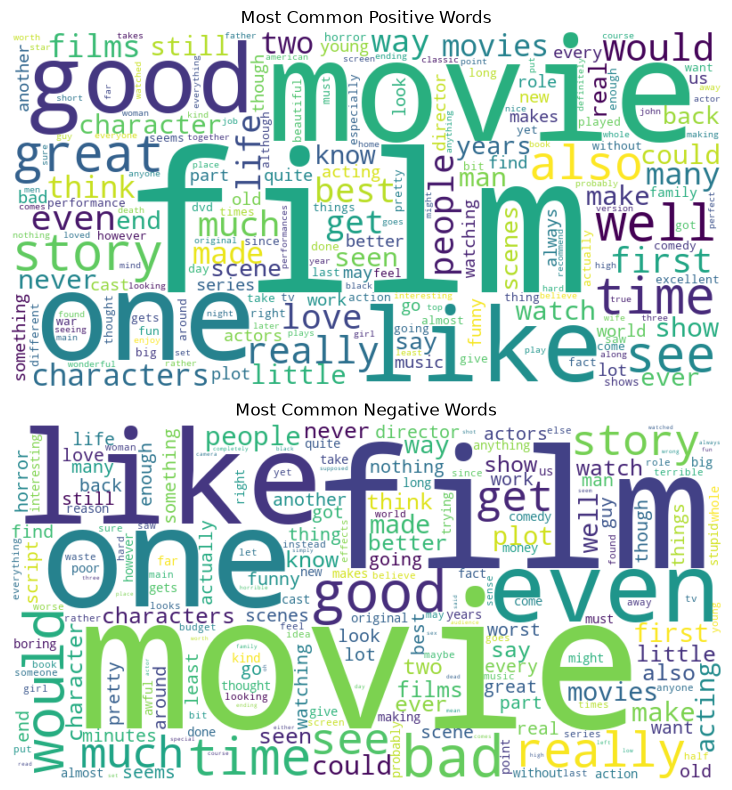

In [103]:
# Get most common words
pos_common_300 = Counter(pos_words).most_common(300)
neg_common_300 = Counter(neg_words).most_common(300)

pos_word_dict = dict(pos_common_300)
neg_word_dict = dict(neg_common_300)

# Generate a word cloud for positive words
pos_wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(pos_word_dict)

# Generate a word cloud for negative words
neg_wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(neg_word_dict)



# Plot the word clouds
plt.figure(figsize=(20, 8))

plt.subplot(2, 1, 1)
plt.imshow(pos_wordcloud, interpolation='bilinear')
plt.title('Most Common Positive Words')
plt.axis('off')

plt.subplot(2, 1, 2)
plt.imshow(neg_wordcloud, interpolation='bilinear')
plt.title('Most Common Negative Words')
plt.axis('off')

plt.tight_layout()
plt.show()

# Assignment

In [104]:
# Assignment, Based on n-gram validate if the sentiment is correct or not
# review[1] = "movie was great, but it can be better" | "Positive"
# "Positive" | "Postive" --> 1
# "Negative" | "Positive" -> 0
# "Negative" | "Negative" --> 1

In [105]:
# "movie great" -> postive / negative
# "great better" -> positive / negative

In [108]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer # sentiment analysis tool that uses a lexicon of words to assign sentiment scores to text. It is particularly effective for social media and short text.

In [109]:
nltk.download('vader_lexicon') # Download the VADER lexicon for sentiment analysis

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\abhis\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [110]:
analyzer = SentimentIntensityAnalyzer()

In [111]:
def get_sentiment(text):
    score = analyzer.polarity_scores(text)['compound']
    if score >= 0.05:
        return "good"
    elif score <= -0.05:
        return "bad"
    else:
        return "neutral"

In [112]:
get_sentiment("movie great")

'good'

In [113]:
get_sentiment("bad movie")

'bad'

In [114]:
get_sentiment("how are you")

'neutral'

In [115]:
get_sentiment("movie was okay")

'good'

In [116]:
get_sentiment("ridiculous movie")

'bad'

In [117]:
# % of correctness / incorrect

# inferential Stats

You aren't doing anything wrong—this is actually one of the most common surprises in statistical analysis!

What you’re experiencing comes down to **sample size** and **statistical power**.

### What’s Happening Under the Hood

A t-test measures whether the difference between two groups (or a group and a reference value) is larger than what you'd expect purely by random chance.

The formula for the t-statistic inherently includes your sample size ($n$):

$$
\text{t-statistic} \approx \frac{\text{Observed Difference}}{\text{Standard Error}} = \frac{\bar{X}_1 - \bar{X}_2}{\frac{s}{\sqrt{n}}}
$$

Notice how $n$ sits in the denominator of the standard error:

- **As $n$ gets very large (e.g., 50,000):** The standard error shrinks toward zero. This makes the t-statistic explode, driving your $p$-value down to virtually $0$.
- **As $n$ is moderate (e.g., 1,000):** The standard error is larger, so the same observed difference yields a smaller t-statistic and a larger $p$-value.

### Statistical Significance vs. Practical Significance

When working with $N = 50,000$, a t-test becomes so sensitive that it will label **tiny, meaningless differences** as "statistically significant" ($p \lt 0.05$).

- **On 50,000 rows:** A microscopic difference in means (e.g., $100.01$ vs $100.03$) will easily get a $p$-value of $0.0001$. The test correctly tells you, *"Yes, we are 99.99% sure these two numbers are not mathematically identical."*
- **On 1,000 rows:** That same microscopic difference doesn't have enough statistical power to prove it isn't noise, giving you $p \gt 0.05$ (fail to reject the null hypothesis).

### Which Result Should You Trust?

> **Rule of thumb for large datasets:** Stop relying purely on $p$-values. When $N$ is large, $p$-values almost always become significant.
>
>

Instead of asking *"Is there a difference?"* (which the t-test answers), ask **"How big is the difference, and does it actually matter?"**

1. **Look at the Effect Size (e.g., Cohen's $d$):** This measures how many standard deviations apart your two groups are, completely independent of sample size.
- Small effect: $\sim 0.2$
- Medium effect: $\sim 0.5$
- Large effect: $\sim 0.8+$
2. **Report Confidence Intervals:** Calculate the 95% confidence interval for the difference between means. This shows you the actual range of the difference in real-world units.

### Next Steps

If your effect size on the 50,000 rows is tiny (e.g., Cohen's $d \lt 0.1$), the "significant" t-test result on the full dataset is just noise amplified by sample size, and the sample of 1,000 is reflecting practical reality.

A **p-value** only answers a binary, yes-or-no question: *"Is there a difference?"* It doesn't tell you if that difference is big enough to care about.

A **95% Confidence Interval (CI) for the difference between means** answers the question that actually matters: *"How big is the difference, in real-world units?"*

### What It Means in Plain English

When you compare two groups (like Group A and Group B), you subtract their sample averages to get a single number—the **observed difference**.

Because your data is a sample, that single number won't be exact. A **95% Confidence Interval** gives you a **plausible range** for what the true difference is in the real world.

> **The "95%" part simply means:** If you repeated this test 100 times with new samples, 95 of those calculated intervals would capture the true population difference.
>
>

### A Real-World Example: E-Commerce Web Design

Imagine you run an A/B test comparing two website designs to see if Design B increases average customer spend per order.

#### Scenario 1: Tiny Difference, Huge Dataset ($N = 50,000$)

- **p-value:** $0.001$ (Statistically significant!)
- **95% Confidence Interval for difference:** **$\$0.02$ to $\$0.05$**

**What this tells you:** You can be 95% confident that Design B increases spend by somewhere between **2 cents and 5 cents per order**.

- *The takeaway:* Even though the p-value says "significant," a 3-cent gain probably isn't worth the cost of redesigning your website.

#### Scenario 2: Meaningful Difference, Large Dataset ($N = 50,000$)

- **p-value:** $0.00001$
- **95% Confidence Interval for difference:** **$\$4.50$ to $\$5.20$**

**What this tells you:** You can be 95% confident that Design B increases average spend by **$\$4.50$ to $\$5.20$ per order**.

- *The takeaway:* This is both statistically significant AND practically valuable.

### How to Read a Confidence Interval Quickly

When looking at a 95% CI for a difference between means, check two things:

| What to look for | What it means |
| --- | --- |
| **Does it cross zero?** *(e.g., $-\$1.20$ to $+\$2.50$)* | If the interval includes zero, it's possible there is **no difference** between the groups (corresponds to $p \gt 0.05$). |
| **How wide is the interval?** *(e.g., $\$0.02$ wide vs $\$10.00$ wide)* | **Narrow intervals** mean high precision (common with $N=50,000$). **Wide intervals** mean low precision/high uncertainty. |

### Summary

With $50,000$ rows, your confidence interval will likely be **extremely narrow**. Looking at those exact lower and upper bounds gives you the concrete numbers you need to judge whether your results are a game-changer or just a statistical fluke.

In [118]:
# Goal 1 :
# Check if review len differs significantly between positive and negative reviews

# H0 : Average review length (in words) is the same for positive and negative review
# H1 : Average review length (in words) is different between positive and negative reviews.

from scipy.stats import ttest_ind

pos_lengths = df[df['sentiment'] == 'positive']['review_word_len']
neg_lengths = df[df['sentiment'] == 'negative']['review_word_len']

t_stat, p_value = ttest_ind(pos_lengths, neg_lengths, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_value)

# Calculate means and median for interpretation
print("Mean words (positive reviews):", pos_lengths.mean())
print("Mean words (negative reviews):", neg_lengths.mean())


print("Median words (positive reviews):", pos_lengths.median())
print("Median words (negative reviews):", neg_lengths.median())


if p_value < 0.05 :
    print(f"We reject H0 ({p_value} < 0.05), average review length is different for positive and negative sentiment")
else :
    print("Fail to reject H0")

T-statistic: 2.208670012690372
P-value: 0.027202144656625855
Mean words (positive reviews): 232.84932
Mean words (negative reviews): 229.46456
Median words (positive reviews): 172.0
Median words (negative reviews): 174.0
We reject H0 (0.027202144656625855 < 0.05), average review length is different for positive and negative sentiment


In [119]:
df_subset = df.sample(n=1000, random_state=200)

pos_lengths_sub = df_subset[df_subset['sentiment'] == 'positive']['review_word_len']
neg_lengths_sub = df_subset[df_subset['sentiment'] == 'negative']['review_word_len']

print(len(pos_lengths_sub), len(neg_lengths_sub))

t_stat_sub, p_value_sub = ttest_ind(pos_lengths_sub, neg_lengths_sub, equal_var=False)

print("T-statistic:", t_stat_sub)
print("P-value:", p_value_sub)

# Calculate means and median for interpretation
print("Mean words (positive reviews):", pos_lengths_sub.mean())
print("Mean words (negative reviews):", neg_lengths_sub.mean())

print("Median words (positive reviews):", pos_lengths_sub.median())
print("Median words (negative reviews):", neg_lengths_sub.median())

if p_value_sub < 0.05 :
    print(f"We reject H0 ({p_value_sub} < 0.05), average review length is different for positive and negative sentiment")
else :
    print("Fail to reject H0")


501 499
T-statistic: 1.1245846825884633
P-value: 0.2610490462372629
Mean words (positive reviews): 233.74850299401197
Mean words (negative reviews): 220.9438877755511
Median words (positive reviews): 173.0
Median words (negative reviews): 167.0
Fail to reject H0


In [120]:
# Chi-Square Test of Independence
# H0 : Average review length (in words) is the same for positive and negative review
# H1 : Average review length (in words) is different between positive and negative reviews.

# Categorial
# word length : Not categorical
# Review length category → categorical (short, long)

# Sentiment → categorical (positive, negative)

df_subset['review_length_cat'] = df_subset['review_word_len'].apply(lambda x: 'short' if x <= 100 else 'long')

In [121]:
contingency = pd.crosstab(df_subset['review_length_cat'], df_subset['sentiment'])
print("Contingency Table:", contingency)


Contingency Table: sentiment          negative  positive
review_length_cat                    
long                    449       433
short                    50        68


In [122]:
from scipy.stats import chi2_contingency

In [123]:
chi2, p, _ , _ = chi2_contingency(contingency)
print("Chi-Square Statistic:", chi2)
print("P-value:", p)

if p < 0.05 :
    print(f"We reject H0 ({p} < 0.05), average review length is different for positive and negative sentiment")
else :
    print("Fail to reject H0")


Chi-Square Statistic: 2.700265384250744
P-value: 0.1003315445463079
Fail to reject H0


# Conclusion : Average review length (in words) is the same for positive and negative review